In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


/tmp/ipykernel_382985/610879476.py:86: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_382985/610879476.py:111: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


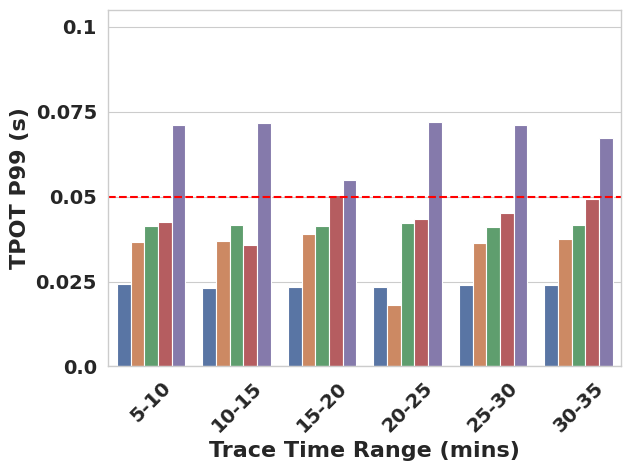

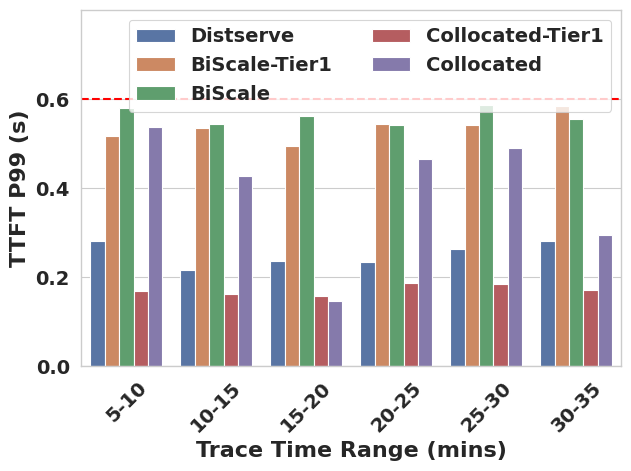

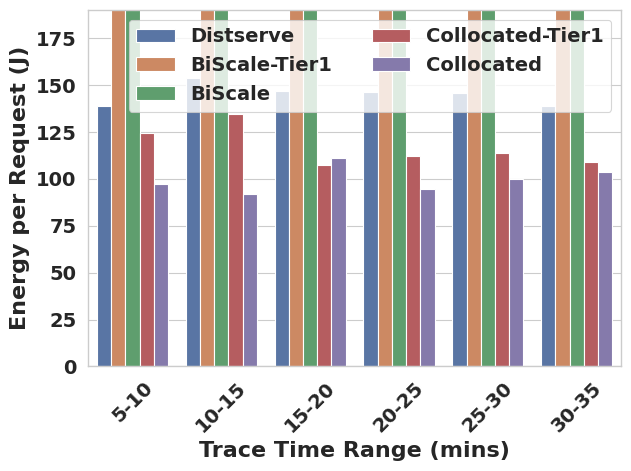

In [ ]:
path_disag = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug17/disag/metrics.csv"
df_results_disag = pd.read_csv(path_disag)

path_coll = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug18/chunked/metrics.csv"
df_results_coll = pd.read_csv(path_coll)

df_results = pd.concat([df_results_disag, df_results_coll], ignore_index=True)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_6': 'Distserve 85',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_5': 'Distserve 70',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_4': 'Distserve 55',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_3': 'Distserve 40',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_2': 'Distserve 25',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_1': 'Distserve 10',
    'OURS_AUG16_AZURE_CONV_P67_6': 'BiScale-Tier1 85',
    'OURS_AUG16_AZURE_CONV_P67_5': 'BiScale-Tier1 70',
    'OURS_AUG16_AZURE_CONV_P67_4': 'BiScale-Tier1 55',
    'OURS_AUG16_AZURE_CONV_P67_3': 'BiScale-Tier1 40',
    'OURS_AUG16_AZURE_CONV_P67_2': 'BiScale-Tier1 25',
    'OURS_AUG16_AZURE_CONV_P67_1': 'BiScale-Tier1 10',
    'OURS_AUG16_AZURE_CONV_P67_6_DVFS': 'BiScale 10',
    'OURS_AUG16_AZURE_CONV_P67_5_DVFS': 'BiScale 25',
    'OURS_AUG16_AZURE_CONV_P67_4_DVFS': 'BiScale 40',
    'OURS_AUG16_AZURE_CONV_P67_3_DVFS': 'BiScale 55',
    'OURS_AUG16_AZURE_CONV_P67_2_DVFS': 'BiScale 70',
    'OURS_AUG16_AZURE_CONV_P67_1_DVFS': 'BiScale 85',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_6': 'Collocated-Tier1 85',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_5': 'Collocated-Tier1 70',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_4': 'Collocated-Tier1 55',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_3': 'Collocated-Tier1 40',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_2': 'Collocated-Tier1 25',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_1': 'Collocated-Tier1 10',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_6_DVFS': 'Collocated 85',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_5_DVFS': 'Collocated 70',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_4_DVFS': 'Collocated 55',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_3_DVFS': 'Collocated 40',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_2_DVFS': 'Collocated 25',
    'OURS_CHUNK_AUG16_AZURE_SHAREGPT_P67_1_DVFS': 'Collocated 10'

}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)

df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.105)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14, fontweight='bold')
ax.legend_.remove()

plt.tight_layout()
plt.savefig("figs/real_67p_trace_tpot_w_coll.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})

plt.tight_layout()
plt.savefig("figs/real_67p_trace_ttft_w_coll_w_coll.pdf", format="pdf")

############################ energy per request - total #######################

df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 190)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
# ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_request_total_w_coll.pdf", format="pdf")


In [21]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_BT1'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_CT1'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Collocated-Tier1')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)
df_results[['expr_dir', 'energy_per_req', 'energy_norm_D', 'energy_norm_BT1', 'energy_norm_CT1']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_req,energy_norm_D,energy_norm_BT1,energy_norm_CT1
36,Distserve 85,125.295542,0.000000,-49.486888,-55.160964
30,Distserve 70,122.868125,0.000000,-51.121944,-56.025795
24,Distserve 55,128.312231,0.000000,-53.332098,-55.050232
18,Distserve 40,127.821564,0.000000,-52.816817,-59.484400
12,Distserve 25,140.324565,0.000000,-56.976605,-64.274401
5,Distserve 10,128.111908,0.000000,-40.560737,-39.811603
29,Collocated-Tier1 85,80.751974,32.196626,-1.357154,0.000000
24,Collocated-Tier1 70,78.748597,33.910891,0.124854,0.000000
19,Collocated-Tier1 55,82.755266,33.360628,-2.179547,0.000000
14,Collocated-Tier1 40,80.146750,35.586573,1.565450,0.000000
